# 01 · Data and exploratory analysis

**Question:** how can financial variables be aligned with quarterly economic growth?

This executable walkthrough uses **fictitious, seeded data** to demonstrate the pipeline. Its charts and correlations are not findings about the US economy. See the repository research note for the separate historical rerun.

In [1]:
from pathlib import Path
import sys
ROOT = Path.cwd() if (Path.cwd() / "macro.py").exists() else Path.cwd().parent
sys.path.insert(0, str(ROOT))
import matplotlib.pyplot as plt
from macro import synthetic_levels, transform, evaluate
plt.rcParams.update({"figure.figsize": (10, 4), "axes.spines.top": False,
                     "axes.spines.right": False, "font.size": 11})
levels = synthetic_levels()
print("SYNTHETIC DEMONSTRATION — not observed US economic data")

Matplotlib is building the font cache; this may take a moment.


SYNTHETIC DEMONSTRATION — not observed US economic data


## Validate the calendar and preserve coverage

The input uses unique calendar quarters. Missing observations are never replaced by zero or forward-filled. GDP, equity, money and credit levels must be positive when observed.

In [2]:
values = transform(levels)
coverage = values.notna().sum().rename("available_quarters").to_frame()
coverage

,available_quarters
GDP_qoq,179
M2_qoq,179
Credit_qoq,179
GDP_yoy,176
SP500_ret,179
Rate_diff,179
Spread_lvl,180
VIX_diff,179


## Financial transformations

GDP qoq is a non-annualized percentage change. GDP yoy is calculated from levels four quarters apart. The term spread is always **10-year minus 2-year yield**. Equity returns use log differences.

In [3]:
values.head(8).round(3)

,GDP_qoq,M2_qoq,Credit_qoq,GDP_yoy,SP500_ret,Rate_diff,Spread_lvl,VIX_diff
Date,,,,,,,,
1980Q1,NaN,NaN,NaN,NaN,NaN,NaN,0.767,NaN
1980Q2,-0.024,1.479,0.641,NaN,3.036,0.111,1.400,-1.185
1980Q3,1.056,1.918,1.509,NaN,-1.376,0.110,0.161,1.752
1980Q4,1.171,0.460,1.163,NaN,9.244,0.107,-0.393,-1.112
1981Q1,-0.569,1.119,1.103,1.633,4.501,0.103,0.942,0.145
1981Q2,-0.181,2.262,1.180,1.473,12.250,0.097,0.554,-1.556
1981Q3,0.679,0.682,1.473,1.095,2.783,0.091,1.226,-2.969
1981Q4,0.411,0.626,0.494,0.336,-7.071,0.083,1.945,-0.437


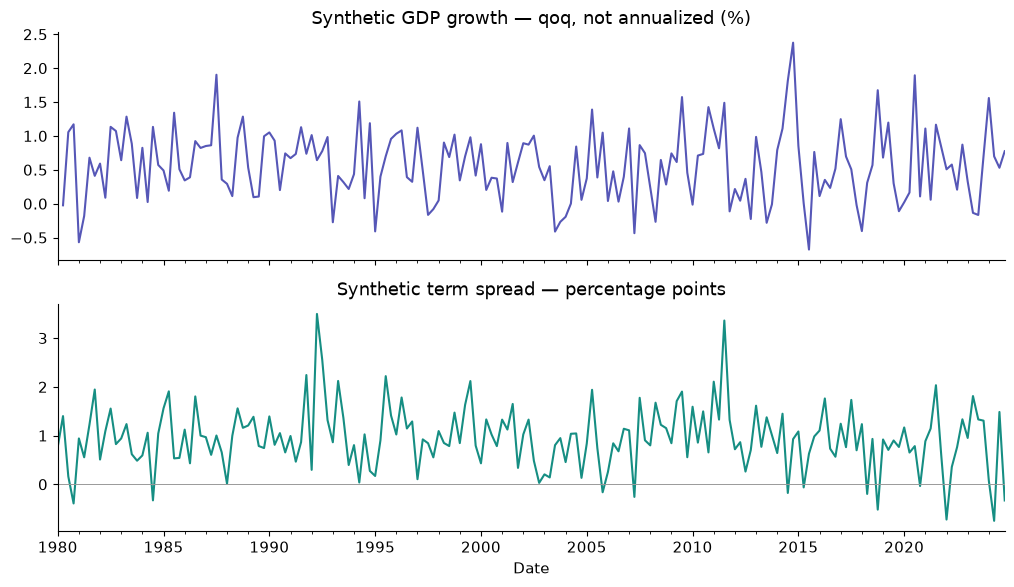

In [4]:
fig, axes = plt.subplots(2, 1, figsize=(10, 6), sharex=True)
values.GDP_qoq.plot(ax=axes[0], color="#5657b7", title="Synthetic GDP growth — qoq, not annualized (%)")
values.Spread_lvl.plot(ax=axes[1], color="#168e83", title="Synthetic term spread — percentage points")
axes[1].axhline(0, color="#999999", linewidth=.7)
fig.tight_layout()
plt.show()

## Correlation is exploratory

All variables below are transformed before comparison. A contemporaneous correlation is neither a causal estimate nor evidence of out-of-sample forecasting performance.

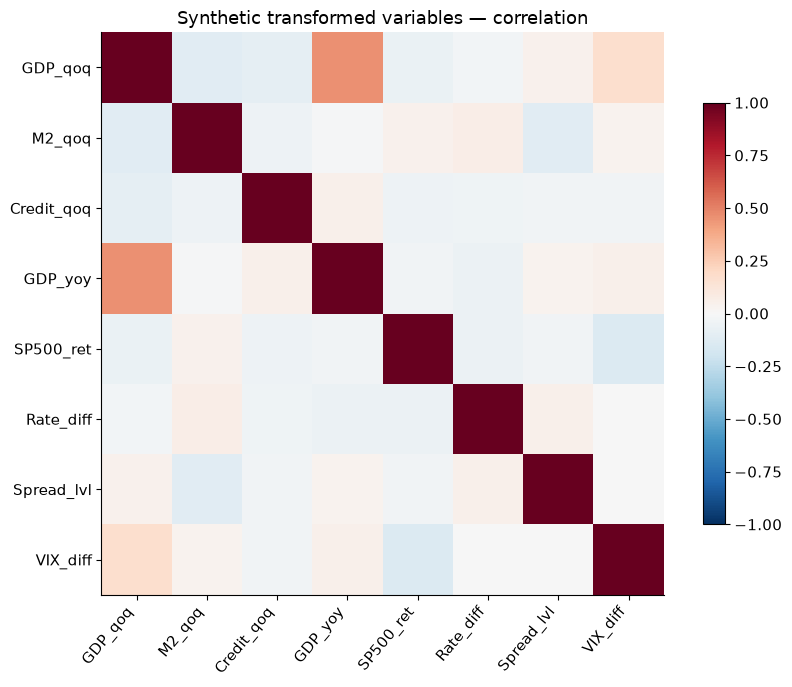

In [5]:
correlation = values.corr()
fig, ax = plt.subplots(figsize=(9, 7))
plot = ax.imshow(correlation, cmap="RdBu_r", vmin=-1, vmax=1)
ax.set_xticks(range(len(correlation)), correlation.columns, rotation=50, ha="right")
ax.set_yticks(range(len(correlation)), correlation.columns)
ax.set_title("Synthetic transformed variables — correlation")
fig.colorbar(plot, ax=ax, shrink=.75)
fig.tight_layout()
plt.show()

## Research interpretation

The synthetic generator creates convenient test inputs, not a realistic macroeconomic model. Before drawing conclusions from real observations, check source vintages, publication delays, aggregation conventions and economic units. In the original data, the two yield series have different sampling frequencies. The next notebook demonstrates a separate temporal evaluation protocol.